In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import lmfit 

from math import factorial

import matplotlib.pyplot as plt

from scipy import optimize

from kineticanalysis.generator.generator_track import (generate_tracks,
                                                        generate_one_track,
                                                        generate_profile)
from kineticanalysis.analysis.analysis_track import (autocorrelation,
                                                    fit_function,
                                                    single_track_analysis,
                                                    fit_autocorrelation_linear,
                                                    fit_autocorrelation_approx)

In [32]:
def generate_one_track(prot_length,
                       suntag_length,
                       nb_suntag,
                       fluo_one_suntag,
                       translation_rate,
                       binding_rate,
                       retention_time=0,
                       suntag_pos="begin",
                       noise=False,
                       noise_std=0,
                       step=0.1,
                       length=6000,
                       ):
    x, y = generate_profile(prot_length,
                            suntag_length,
                            nb_suntag,
                            fluo_one_suntag,
                            translation_rate,
                            retention_time,
                            suntag_pos,
                            step,
                            noise,
                            noise_std
                            )

    # global signal
    x_global = np.arange(length, step=step)
    y_global = np.zeros(len(x_global))
    y_start_prot = np.zeros(len(x_global))

    n_rand = np.random.rand(len(x_global))
    for i in range(len(x_global)):
        # random number between 0 and 1
        if n_rand[i] < (binding_rate * step):
            if i > (len(x_global) - len(x)):
                y_global[i:i + len(x)] += y[:len(y_global[i:i + len(x)])]
                y_start_prot[i:i + len(x)] += 1
            else:
                y_global[i:i + len(x)] += y
                y_start_prot[i:i + len(x)] += 1

    # Remove the first time points
    # x_global = x_global[2000:] - 200  # -200 to start time at 0
    # y_global = y_global[2000:]
    # y_start_prot = y_start_prot[2000:]

    return x_global, y_global, y_start_prot


def autocorrelation_manual(intensity, lags):
    I = np.array(intensity, dtype=float)
    N = len(I)

    # Mean intensity
    I_mean = np.mean(I)
    delta_I = I - I_mean

    # Compute autocorrelation via FFT (efficient method)
    # Pad to 2N for no circular overlap
    f = np.fft.fft(delta_I, n=2*N)
    ac = np.fft.ifft(f * np.conjugate(f))[:N].real

    # Normalize
    ac /= np.arange(N, 0, -1)   # correct for reduced pairs at long τ
    G = ac / (I_mean ** 2)

    # Lag times
    tau = np.arange(N)

    return tau, G


def fit_function_exact(x, k, c, N):
    return (k/c)*(2/3)*(1/((N*(N+1))**2)) * np.exp(-k*x) * (
        sum((N-n)*(N-n+1)*((2*N)+n+1)*(((k*x)**n)/factorial(n)) for n in range (0, int(N)))
    )
    
def fit_function_exact_v2(x, k, c, N):
    sum_ = []
    for n in range (0, int(N), 1):
        sum_.append((N-n)*(N-n+1)*((2*N)+n+1)*(((k*x)**n)/factorial(n)))
    return (k/c)*(2/3)*(1/((N*(N+1))**2)) * np.exp(-k*x) * np.sum(sum_, axis=0)

def fit_function_exact_v3(x, k, c, N, M):
    denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
       
    part1 = c/k*np.exp(-k*x) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*x)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
    
    part2 = c/k*np.exp(-k*x) * N * sum(n * ((2*N-n+1)/2) * ((k*x)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
    part3 = c/k*np.exp(-k*x) * (N**2) * ((N+1)/2) * sum(((k*x)**n)/(np.float128(factorial(int(n)))) for n in range (int(N), int(M))) /denominator
    part4 = c/k*np.exp(-k*x) * N * sum(n *( (1+n)/2) * (((k*x)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
    
    part5 = c/k*np.exp(-k*x) * (N**2) * sum((M-n)*(((k*x)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator
    print(part1+part2+part3+part4+part5)
    return part1+part2+part3+part4+part5

# model = lmfit.Model(fit_function_exact)
# params = lmfit.Parameters() 
# params.add('N', value=32, vary=False)
# params.add('k', value=1, min=0)
# params.add('c', value=1, min=0)

# result = model.fit(y_auto3, params, x=np.arange(0,len(y_auto3)))

# result


In [20]:
suntag_length = 796
prot_length = 480
nb_suntag = 32
fluo_one_suntag = 4
translation_rate = 15
binding_rate = 0.33
step = 0.1
length = 6000


x_global, y_global, y_start = generate_one_track(prot_length=prot_length,
                                                   suntag_length=suntag_length,
                                                   nb_suntag=nb_suntag,
                                                   fluo_one_suntag=fluo_one_suntag,
                                                   translation_rate=translation_rate,
                                                   binding_rate=binding_rate,
                                                   step=step,
                                                   length=length)

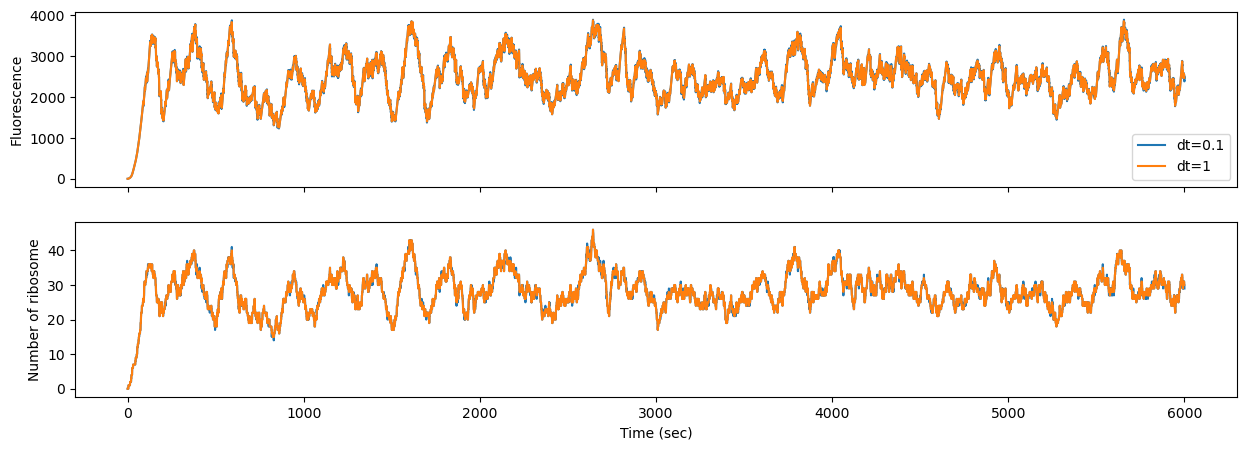

In [21]:
fig, axes = plt.subplots(nrows = 2, sharex=True)
max_ = 60000 # nb_point
step_ = 1
axes[0].plot(x_global[::step_][:max_], y_global[::step_][:max_], label="dt=0.1")
axes[1].plot(x_global[::step_][:max_], y_start[::step_][:max_])

max_ = 6000  # nb point
step_ = 10
axes[0].plot(x_global[::step_][:max_], y_global[::step_][:max_], label="dt=1")
axes[1].plot(x_global[::step_][:max_], y_start[::step_][:max_])

axes[0].legend()
axes[0].set_ylabel("Fluorescence")
axes[1].set_ylabel("Number of ribosome")
axes[1].set_xlabel("Time (sec)")

fig.set_size_inches((15,5))

0.3986783367287374 0.46343325061373264
10.957857055481186


/tmp/ipykernel_1029502/1918149884.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  datas = pd.concat([datas,


0.46777708687386177 0.33283630392181096
11.832693180487801
0.2747038470529106 0.2146258295448109
7.052038336269376
0.24970496579058432 0.2537348065980527
6.596672189100685
0.39606964064118166 0.3813761076252842
10.057403226254204
0.3741498074965164 0.3581682538756461
9.46495993425081
1.2215306456785076 0.7244502662454462
32.047946003032195
1.8531441617954143 0.6667963763123608
46.02475158989602
0.817831859006741 0.5071005763391645
21.570880712312526
0.5317763055461759 0.4340911199748796
14.656954069482966
0.7368186469906932 0.5168563723944863
20.442803159737775
1.3732290316369045 0.6436789823278963
35.34750701802702
1.4618085589168155 0.501835785885812
32.45255889583941
1.3649828364405483 0.5412248477495194
32.92287975874334
1.5673601793779235 0.7182927188168655
41.99338659269123
1.794050413187486 0.7790749830383996
46.595683627444515
1.046835705078272 0.5748614589157346
27.960492124443906


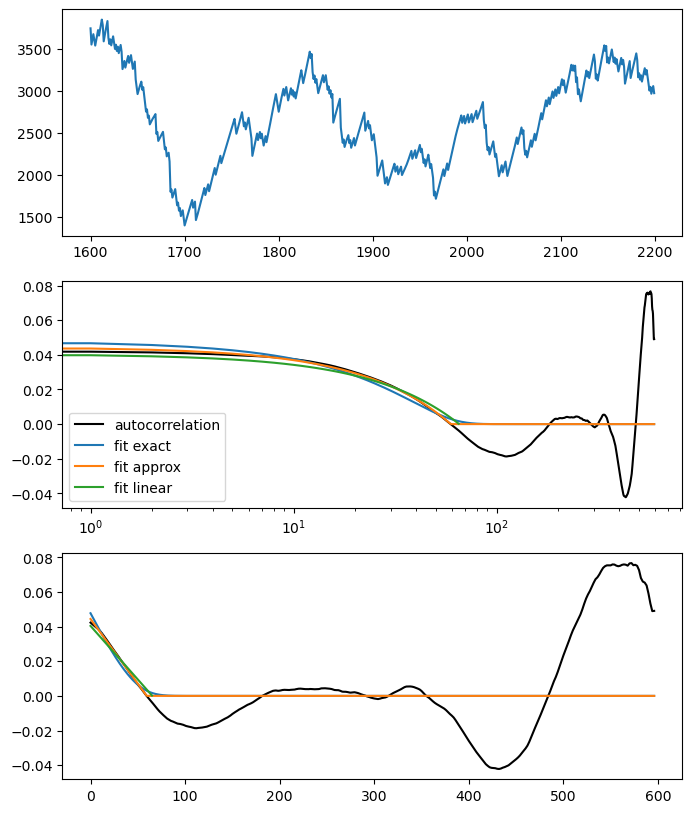

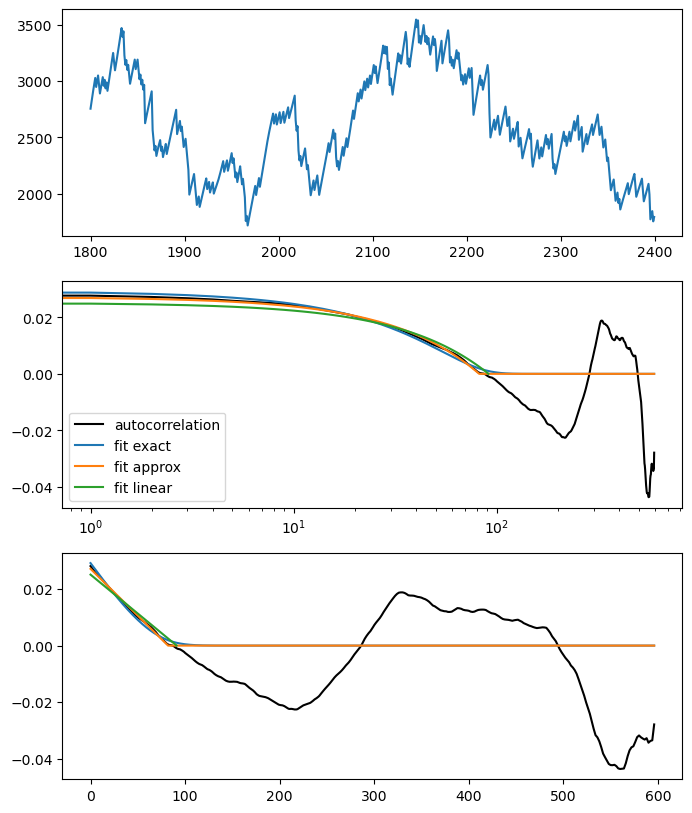

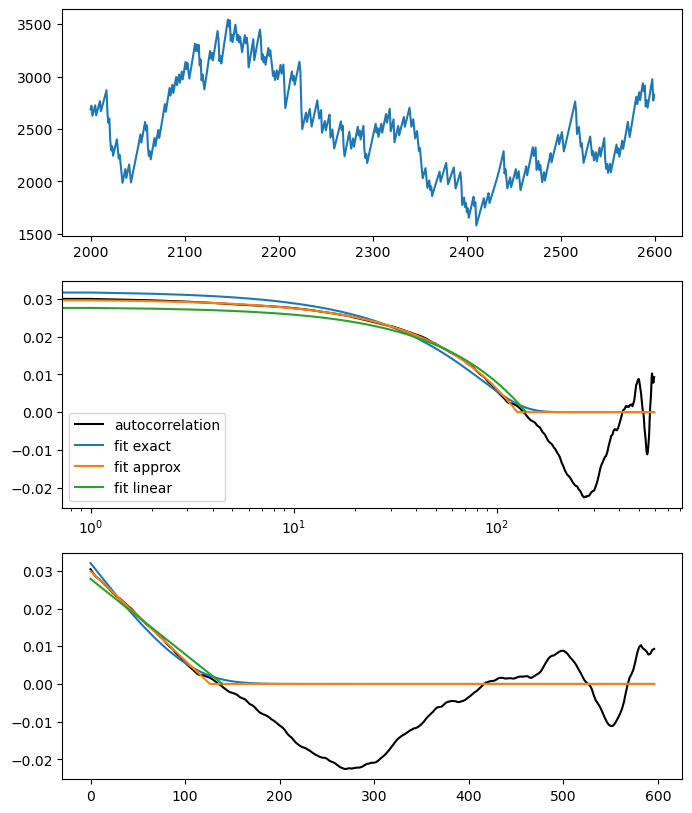

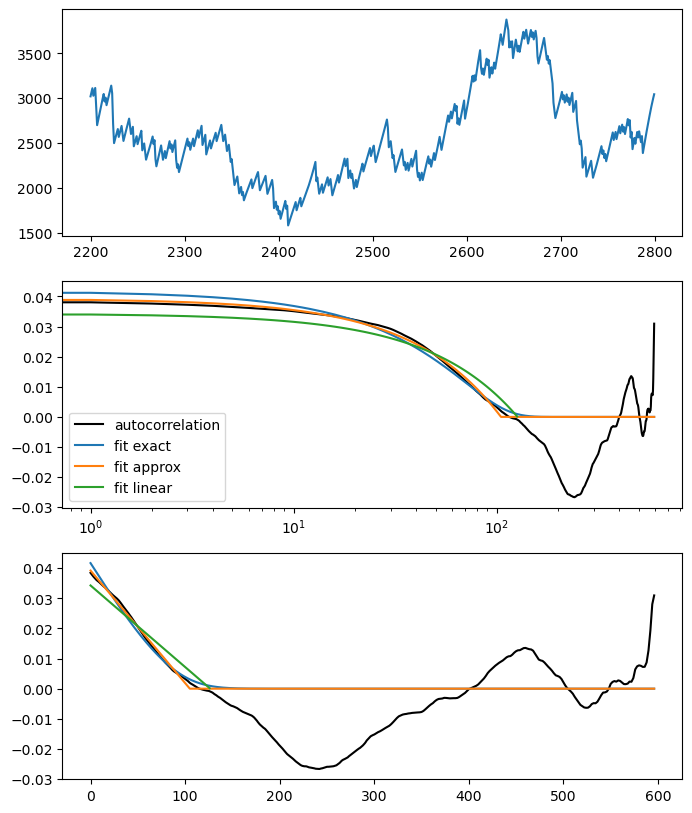

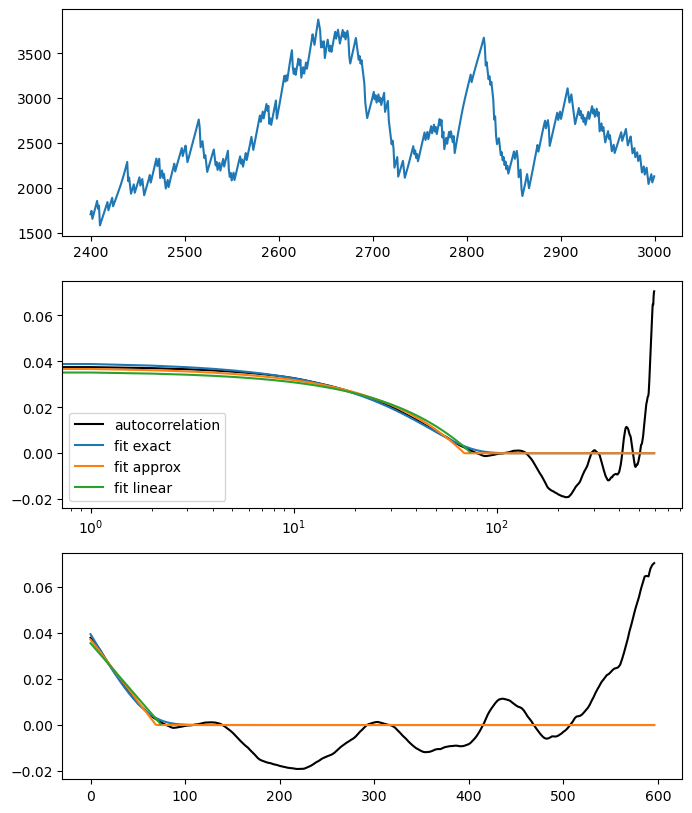

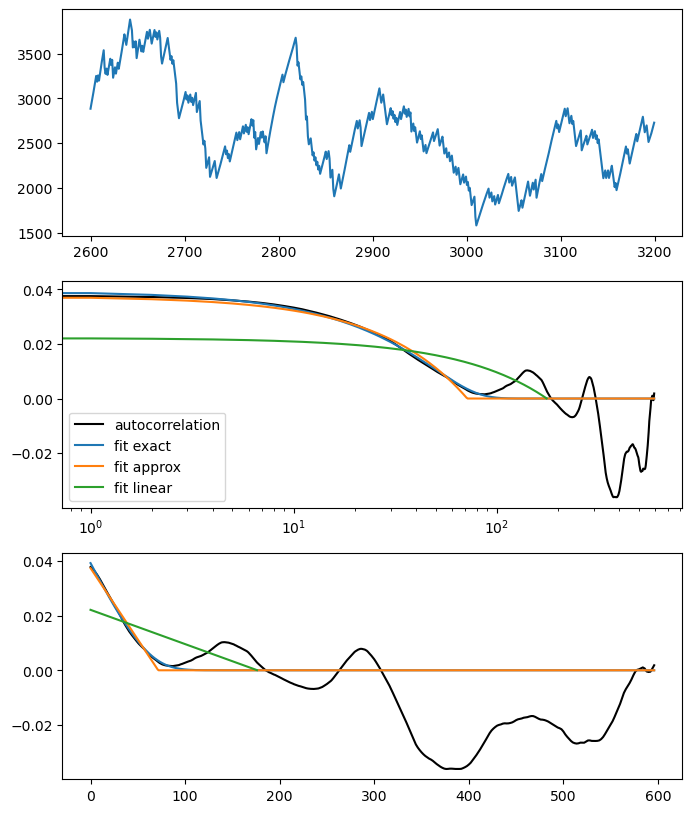

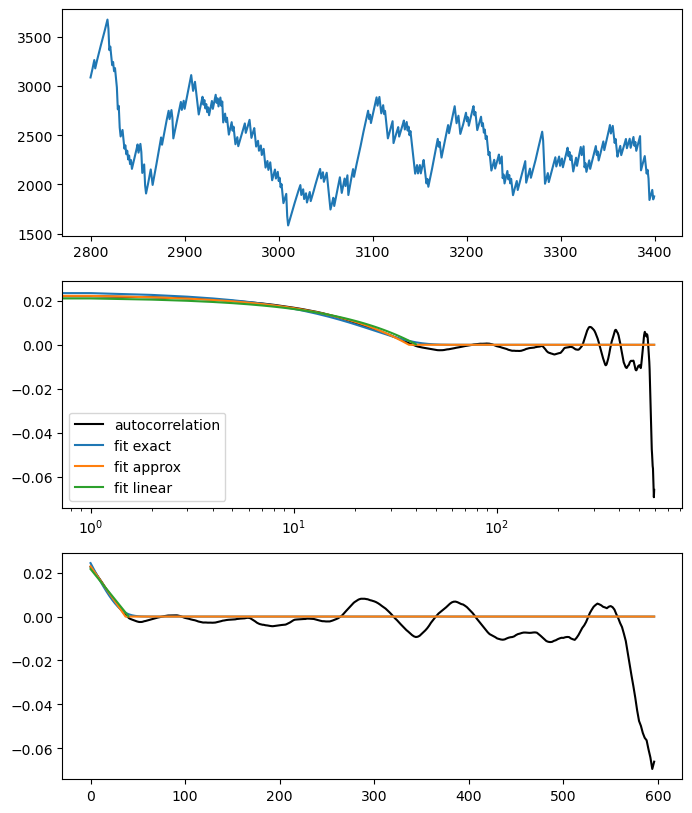

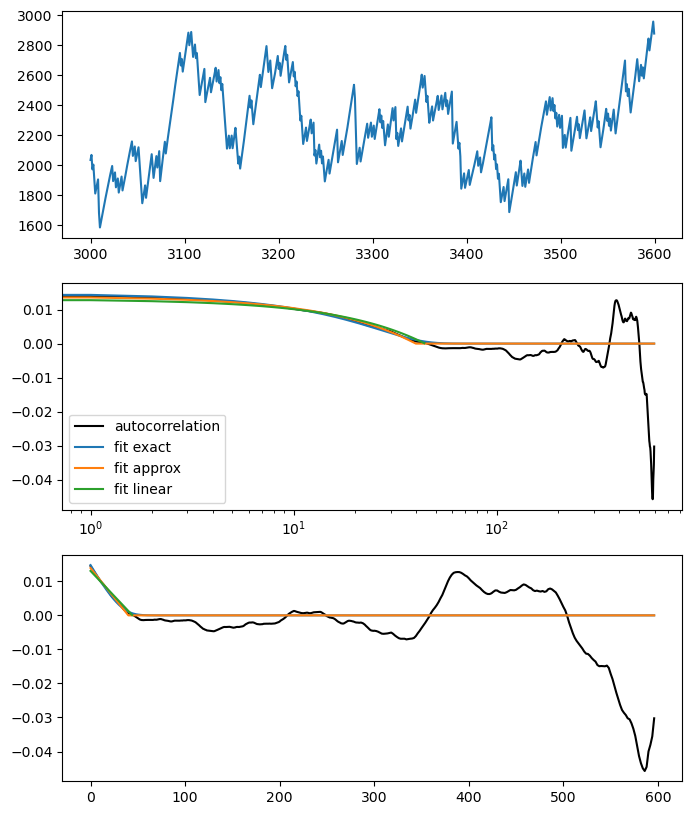

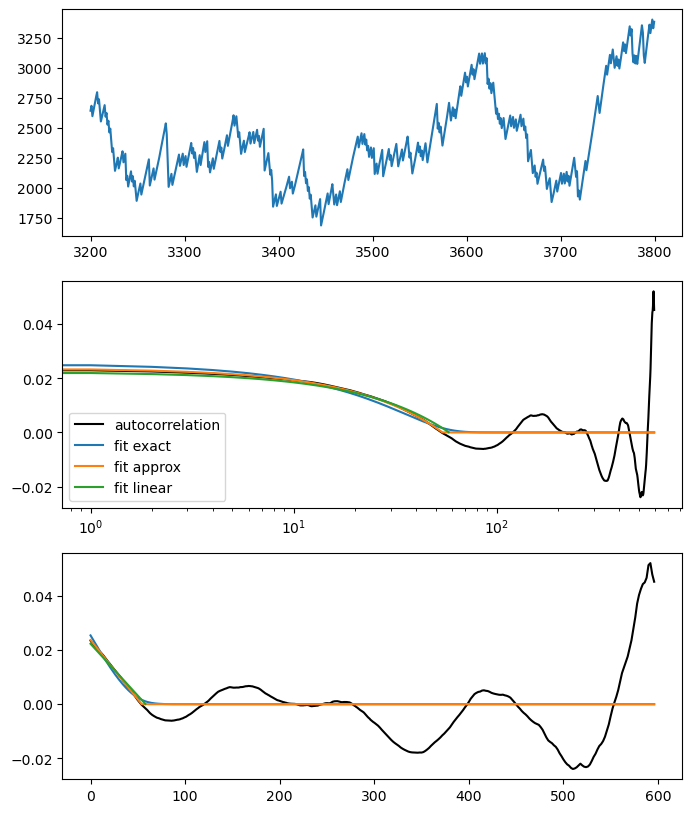

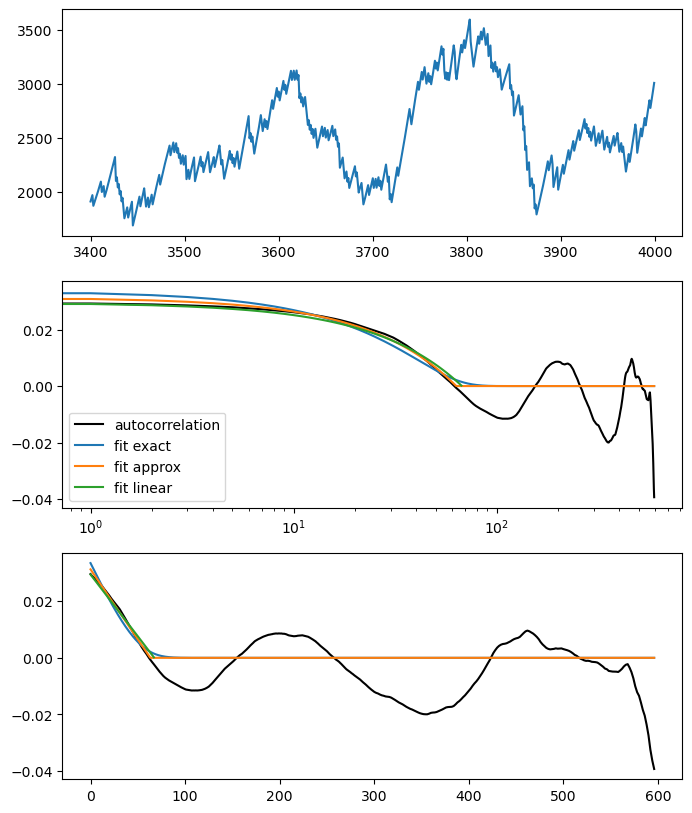

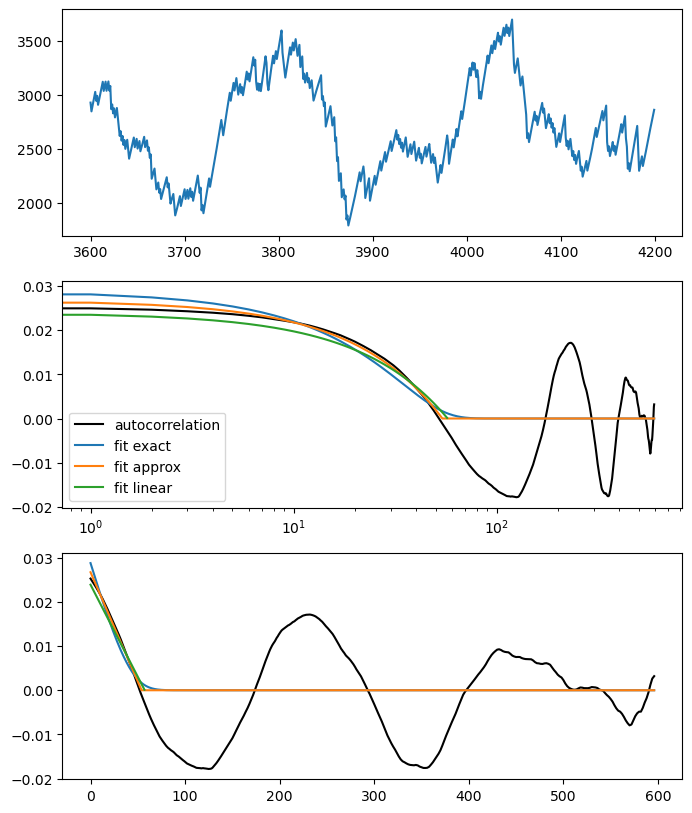

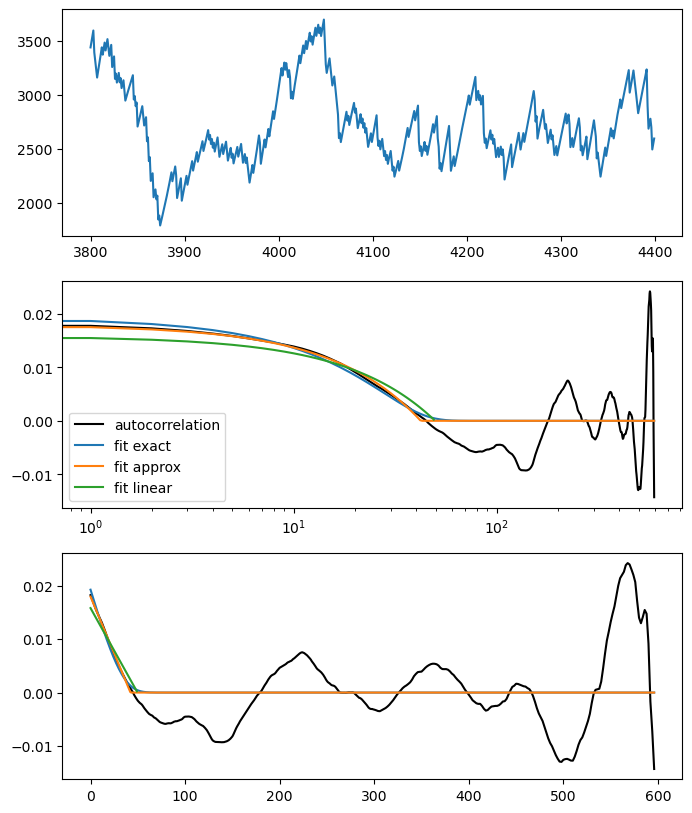

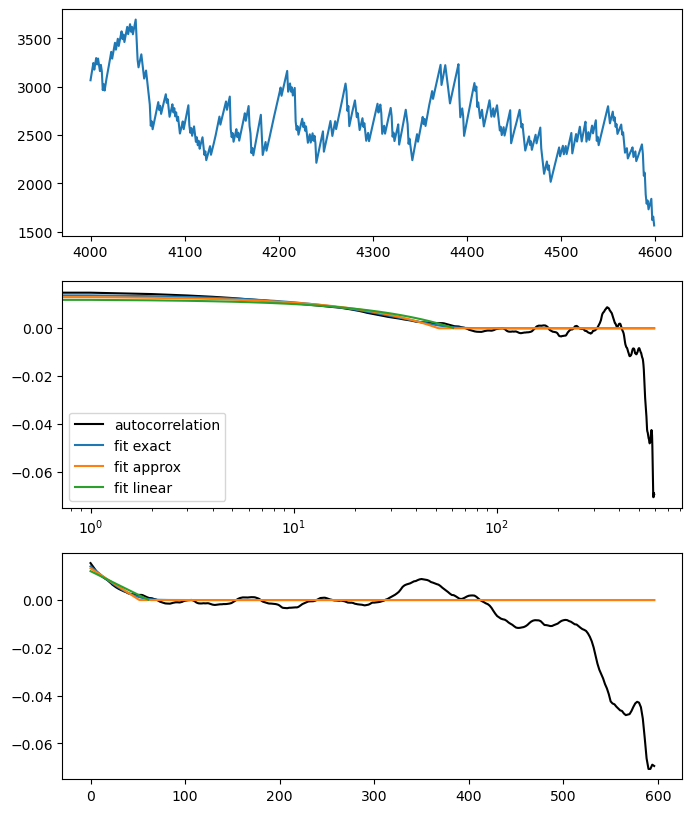

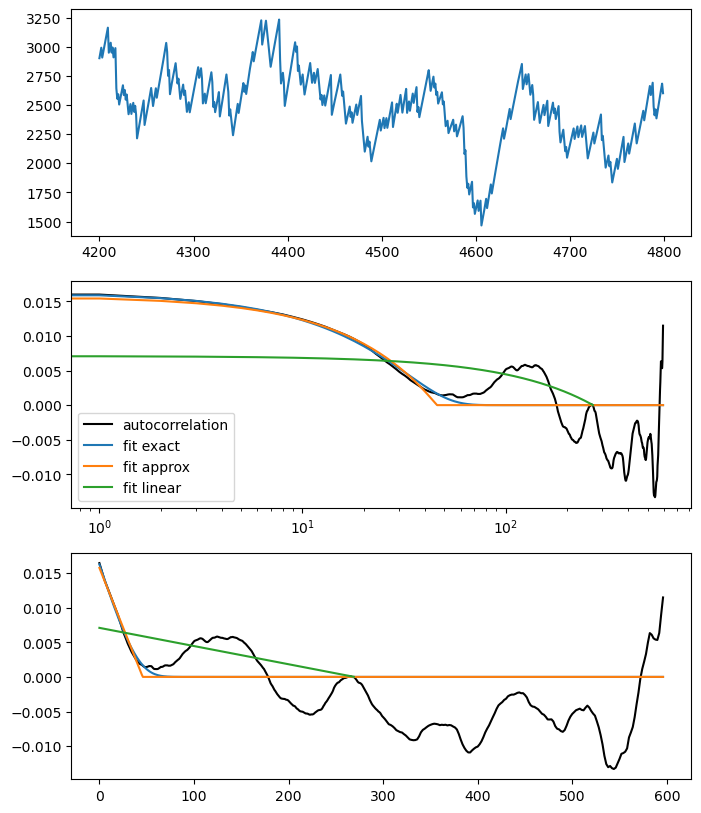

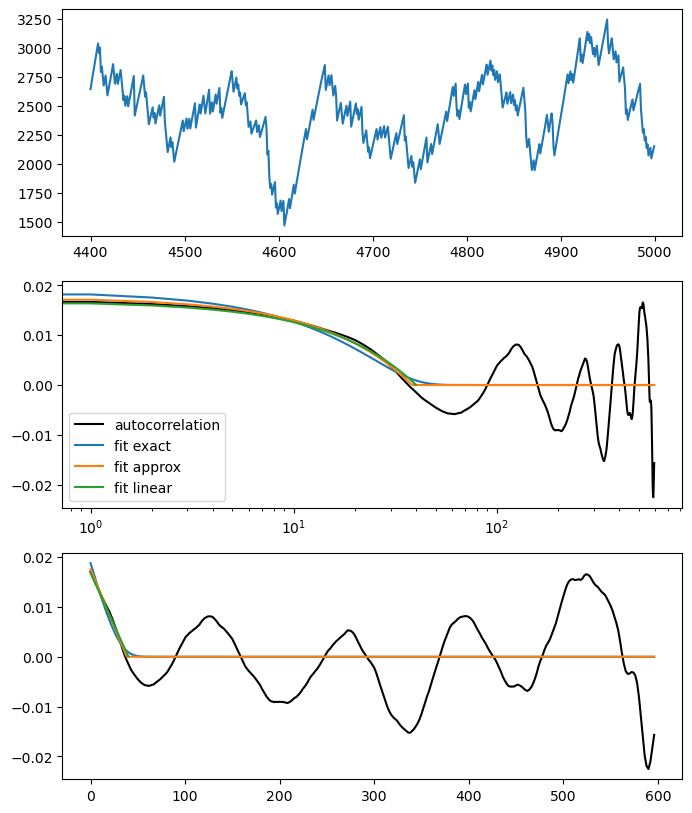

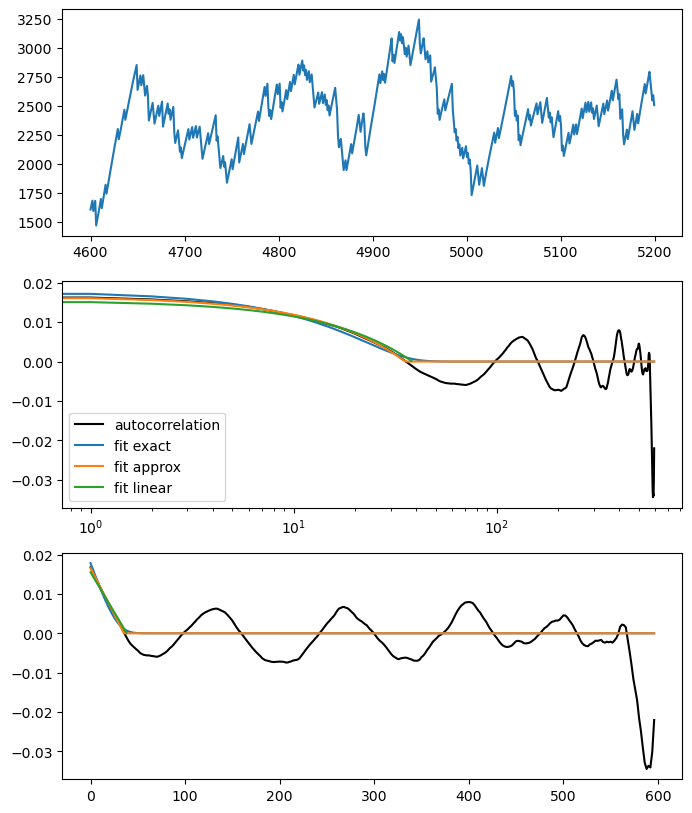

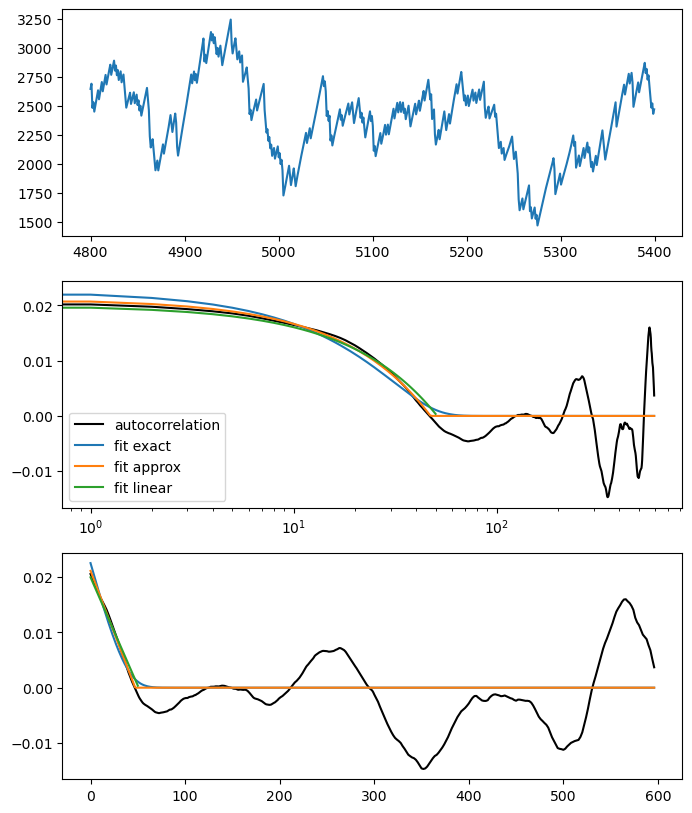

In [27]:
mins = np.arange(1600, 5000, 200)
maxs = mins+600
step = 10

datas = pd.DataFrame(columns=["start", "end", "k_approx", "c_approx", "k_linear", "c_linear","k_full", "c_full"])

for min_i, max_i in zip(mins, maxs):
    
    x_auto, y_auto = autocorrelation(y_global[::step][min_i:max_i], np.nan)
    
    x_auto, y_auto = autocorrelation(y_global[::step][min_i:max_i], 
                                    delta_t=1.)

    # analysis
    approx_k, approx_c, perr=fit_autocorrelation_approx(x_auto, y_auto, protein_size= suntag_length+prot_length)
    # print(c_elongation_r, c_translation_init_r)

    lin_k, lin_c, perr = fit_autocorrelation_linear(x_auto, y_auto, suntag_length+prot_length)
    # print(l_elongation_r, l_translation_init_r)
    
    # analysis full equation
    model = lmfit.Model(fit_function_exact)
    params = lmfit.Parameters() 
    params.add('N', value=32, vary=False)
    params.add('k', value=1, min=0)
    params.add('c', value=1, min=0)
    
    result = model.fit(y_auto, params, x=np.arange(0,len(y_auto)))
    print(result.params["c"].value, result.params["k"].value)
    print(result.params["k"].value/y_auto[0],)
    
    # print(result.params["k"], result.params["c"])

    datas = pd.concat([datas,
                         pd.DataFrame(
                             {"start": min_i,
                              "end":max_i, 
                              "k_approx": approx_k, 
                              "c_approx": approx_c, 
                              "k_linear": lin_k, 
                              "c_linear": lin_c, 
                              "k_full":result.params["k"].value, 
                              "c_full": result.params["c"].value}, index=[0])
                         ], ignore_index=True)


    fig, axes = plt.subplots(nrows=3)

    axes[0].plot(x_global[::step][min_i:max_i], 
             y_global[::step][min_i:max_i])

    axes[1].plot(x_auto, y_auto, c="black", label="autocorrelation")
    axes[1].plot(x_auto, fit_function_exact(x_auto, result.params["k"].value, result.params["c"].value, result.params["N"].value), label = "fit exact")
    axes[1].plot(x_auto, fit_function(x_auto, approx_k, approx_c)[:int(len(x_auto))], label = "fit approx")
    axes[1].plot(x_auto[:int(-lin_c/lin_k)+1], (x_auto*lin_k+lin_c)[:int(-lin_c/lin_k)+1], label = "fit linear")

    axes[2].plot(x_auto, y_auto, c="black", label="autocorrelation")
    axes[2].plot(x_auto, fit_function_exact(x_auto, result.params["k"].value, result.params["c"].value, result.params["N"].value), label = "fit exact")
    axes[2].plot(x_auto, fit_function(x_auto, approx_k, approx_c)[:int(len(x_auto))], label = "fit approx")
    axes[2].plot(x_auto[:int(-lin_c/lin_k)+1], (x_auto*lin_k+lin_c)[:int(-lin_c/lin_k)+1], label = "fit linear")
    
    axes[1].set_xscale("log")
    # ax.set_yscale("log")
    axes[1].legend()
    fig.set_size_inches((8,10))
    fig.savefig(str(min_i)+str(max_i)+".png")

In [28]:
one_loop_size = 24
datas["k_approx_calculated"] = (suntag_length)/datas["k_approx"]

datas["k_linear_calculated"] = suntag_length/(-(datas["c_linear"]/datas["k_linear"]))

# datas["k_full_calculated"] = one_loop_size/(1/(datas["k_full"]))
datas["k_full_calculated"] = datas["k_full"]*one_loop_size

N=32
datas["full_dwelltime"] = N/datas["k_full_calculated"]
# datas["k_full_calculated"] = (suntag_length/one_loop_size)/(1/datas["k_full"])

In [29]:
datas.agg(["mean", "std"])

,start,end,k_approx,c_approx,k_linear,c_linear,k_full,c_full,k_approx_calculated,k_linear_calculated,k_full_calculated,full_dwelltime
mean,3200.000000,3800.000000,60.120738,0.907046,-0.00034,0.022530,0.506614,0.937085,14.996531,12.532836,12.158736,2.986390
std,1009.950494,1009.950494,24.937682,0.541091,0.00015,0.008962,0.166052,0.556887,4.842290,5.512049,3.985250,1.238946


In [30]:
datas.head(20)

,start,end,k_approx,c_approx,k_linear,c_linear,k_full,c_full,k_approx_calculated,k_linear_calculated,k_full_calculated,full_dwelltime
0,1600,2200,59.429815,0.379099,-0.000618,0.040384,0.463433,0.398678,13.393951,12.183976,11.122398,2.877077
1,1800,2400,81.958369,0.449202,-0.000276,0.025122,0.332836,0.467777,9.712248,8.732689,7.988071,4.005973
2,2000,2600,126.231467,0.264694,-0.000200,0.027861,0.214626,0.274704,6.305876,5.703762,5.151020,6.212362
3,2200,2800,104.909469,0.243070,-0.000271,0.034274,0.253735,0.249705,7.587494,6.288296,6.089635,5.254830
4,2400,3000,69.291273,0.387904,-0.000475,0.035598,0.381376,0.396070,11.487738,10.618653,9.153027,3.496111
5,2600,3200,71.578647,0.373089,-0.000126,0.022156,0.358168,0.374150,11.120635,4.510877,8.596038,3.722645
6,2800,3400,36.955006,1.182690,-0.000535,0.021639,0.724450,1.221531,21.539707,19.676537,17.386806,1.840476
7,3000,3600,39.859679,1.805203,-0.000294,0.013053,0.666796,1.853144,19.970055,17.943614,16.003113,1.999611
8,3200,3800,54.031503,0.779994,-0.000384,0.022350,0.507101,0.817832,14.732146,13.669685,12.170414,2.629327
9,3400,4000,63.198360,0.505753,-0.000437,0.029455,0.434091,0.531776,12.595263,11.807281,10.418187,3.071552


<Axes: >

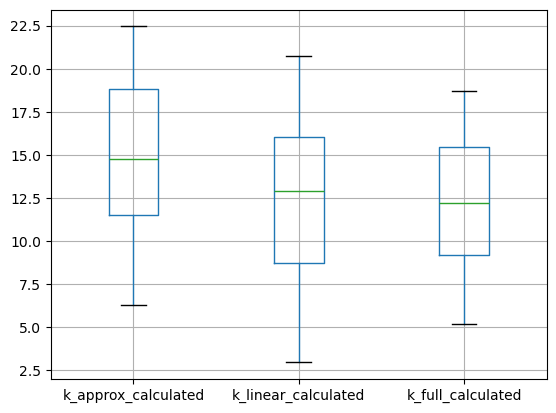

In [31]:
datas.boxplot(["k_approx_calculated","k_linear_calculated", "k_full_calculated"])

# Analyse full equation - each term evaluation

/tmp/ipykernel_1029502/2993516085.py:90: RuntimeWarning: overflow encountered in power
  part3 = c/k*np.exp(-k*x) * (N**2) * ((N+1)/2) * sum(((k*x)**n)/(np.float128(factorial(int(n)))) for n in range (int(N), int(M))) /denominator
/tmp/ipykernel_1029502/2993516085.py:91: RuntimeWarning: overflow encountered in power
  part4 = c/k*np.exp(-k*x) * N * sum(n *( (1+n)/2) * (((k*x)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
/tmp/ipykernel_1029502/2993516085.py:93: RuntimeWarning: overflow encountered in power
  part5 = c/k*np.exp(-k*x) * (N**2) * sum((M-n)*(((k*x)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator


[0.1478449  0.14766489 0.14747699 0.14728142 0.14707838 0.1468681
 0.14665077 0.14642662 0.14619584 0.14595866 0.14571529 0.14546593
 0.1452108  0.14495011 0.14468406 0.14441288 0.14413677 0.14385594
 0.14357061 0.14328098 0.14298727 0.14268969        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf
        inf        inf        inf        inf        inf        

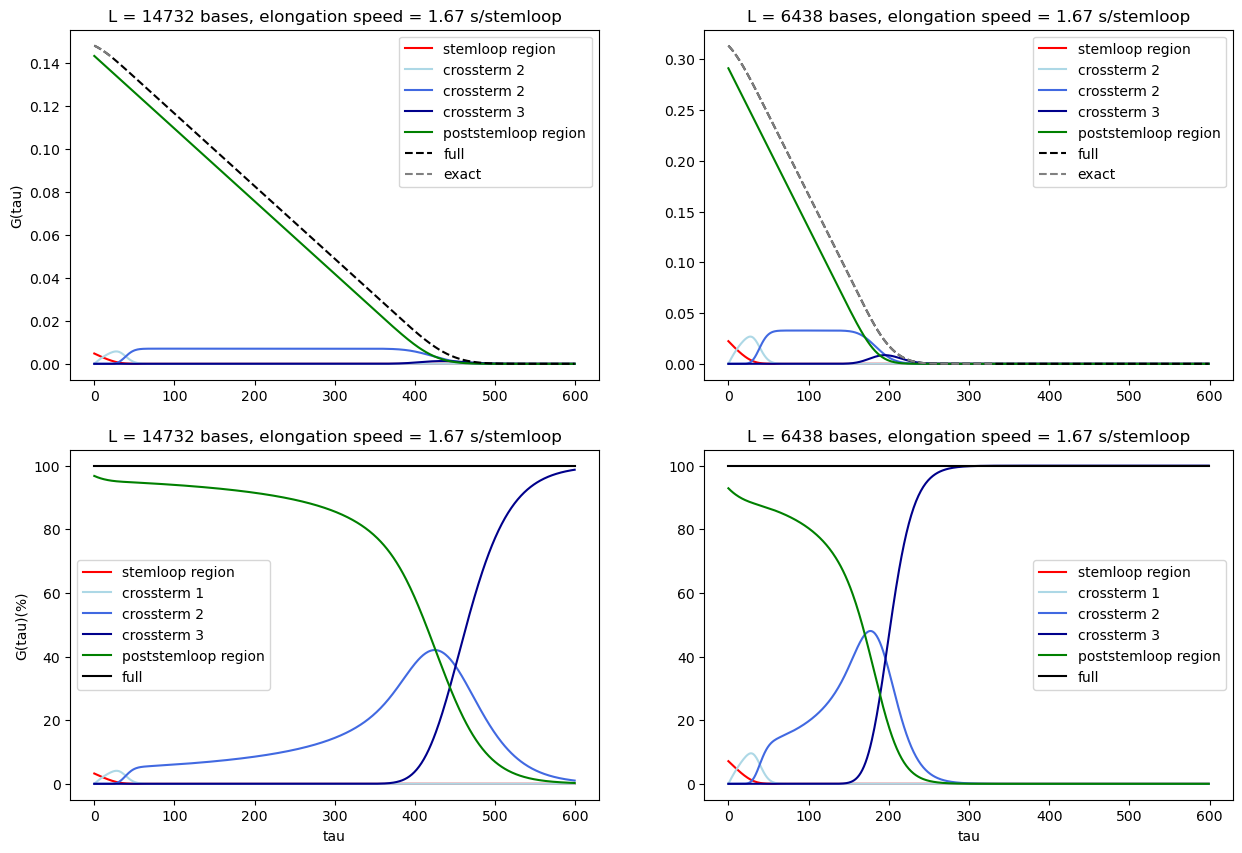

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from decimal import Decimal

#number of stem loop
N = 24
#stem loop size
s = 58
k = 0.6
c = 0.015

tau = np.arange(0, np.int64(600))

fig, axes = plt.subplots(ncols=2, nrows = 2, sharey =False)

# gene 1
#length of gene
L = 14732
# L= 6438

i=0
for L in [14732, 6438]:

    M = L/s
    
    denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
    
    k = np.float128(k)
    c = np.float128(c)
    
    part1 = c/k*np.exp(-k*tau) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*tau)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
    
    part2 = c/k*np.exp(-k*tau) * N * sum(n * ((2*N-n+1)/2) * ((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
    part3 = c/k*np.exp(-k*tau) * (N**2) * ((N+1)/2) * sum(((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (N, int(M))) /denominator
    part4 = c/k*np.exp(-k*tau) * N * sum(n *( (1+n)/2) * (((k*tau)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
    
    part5 = c/k*np.exp(-k*tau) * (N**2) * sum((M-n)*(((k*tau)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator
    
    axes[0,i].plot(tau, part1, label="stemloop region", color="red")
    
    axes[0,i].plot(tau, part2, label="crossterm 2", color="lightblue")
    axes[0,i].plot(tau, part3, label="crossterm 2",  color="royalblue")
    axes[0,i].plot(tau, part4, label="crossterm 3",  color="darkblue")
    axes[0,i].plot(tau, part5, label="poststemloop region", color="green")

    axes[0,i].plot(tau, part1+part2+part3+part4+part5, '--', label="full", color="black")

    # axes[0,i].plot(tau, fit_function_exact(tau, float(k), float(c), N), "--", label="exact", color="grey")
    # axes[0,i].plot(tau, fit_function_exact_v3(tau, float(k), float(c), N,M), "--", label="exact", color="grey")
    
    # axes[0,i].set_ylim(0, 0.5)
    axes[0,i].set_title("L = " + str(L)+ " bases, elongation speed = " + str(np.round(1/k,2))+" s/stemloop")
    axes[0,i].legend()


    # percentage
    axes[1,i].plot(tau, part1*100/(part1+part2+part3+part4+part5), label="stemloop region", color="red")    
    axes[1,i].plot(tau, part2*100/(part1+part2+part3+part4+part5), label="crossterm 1", color="lightblue")  
    axes[1,i].plot(tau, part3*100/(part1+part2+part3+part4+part5), label="crossterm 2",  color="royalblue")    
    axes[1,i].plot(tau, part4*100/(part1+part2+part3+part4+part5), label="crossterm 3",  color="darkblue")    
    axes[1,i].plot(tau, part5*100/(part1+part2+part3+part4+part5), label="poststemloop region", color="green")
    
    axes[1,i].plot(tau, (part1+part2+part3+part4+part5)*100/(part1+part2+part3+part4+part5),  label="full", color="black")
    
    axes[1,i].set_title("L = " + str(L)+ " bases, elongation speed = " + str(np.round(1/k,2))+" s/stemloop")
    axes[1,i].legend()

    i+=1
axes[1,0].set_xlabel("tau")
axes[1,1].set_xlabel("tau")
axes[0,0].set_ylabel("G(tau)")
axes[1,0].set_ylabel("G(tau)(%)")

# axes[0,0].vlines(3683,0,0.01)
# axes[1,0].vlines(3683,0,100)

fig.set_size_inches(15,10)

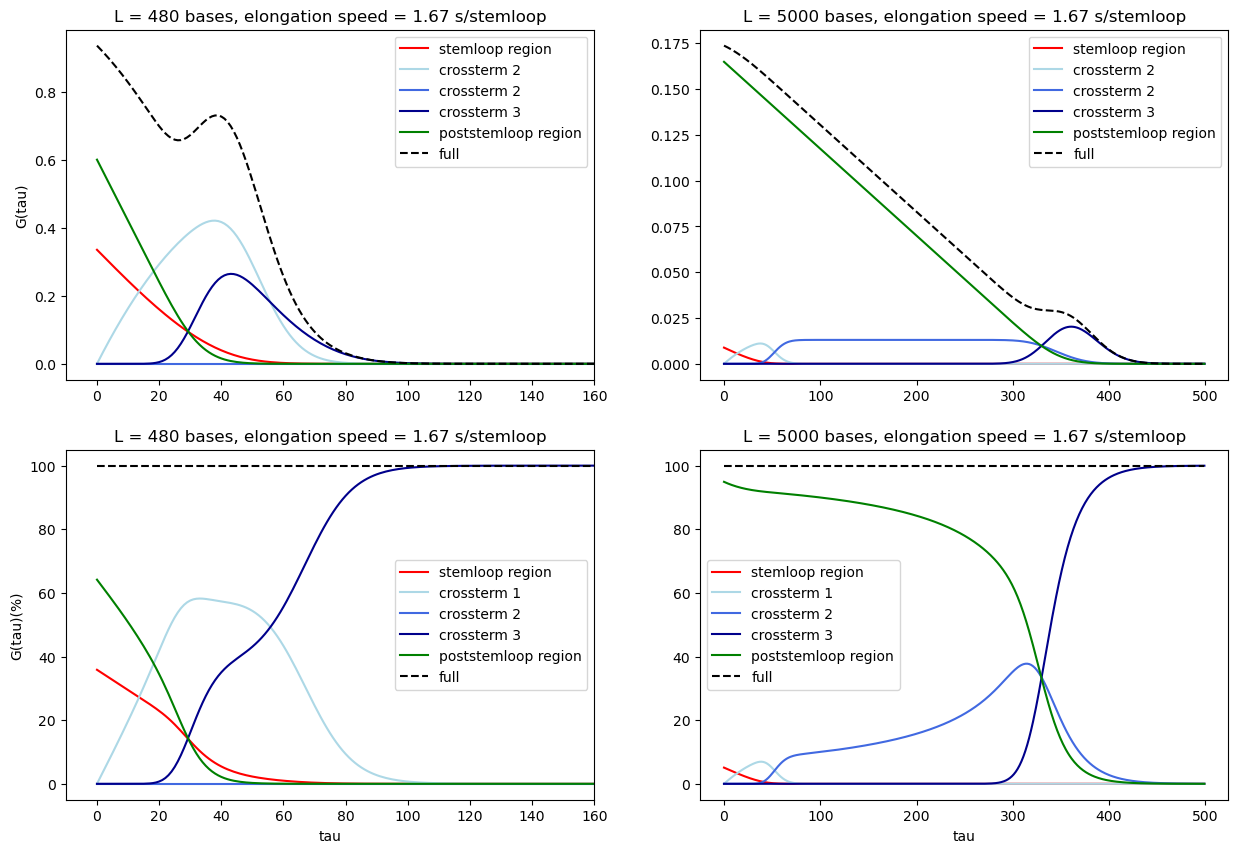

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from decimal import Decimal

#number of stem loop
N = 32
#stem loop size
s = 24
k = 0.6
c = 0.015

tau = np.arange(0, np.int64(500))

fig, axes = plt.subplots(ncols=2, nrows=2, sharey =False)


i=0
for L in [480, 5000]:

    M = L/s
    
    denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
    
    k = np.float128(k)
    c = np.float128(c)
    
    part1 = c/k*np.exp(-k*tau) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*tau)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
    
    part2 = c/k*np.exp(-k*tau) * N * sum(n * ((2*N-n+1)/2) * ((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
    part3 = c/k*np.exp(-k*tau) * (N**2) * ((N+1)/2) * sum(((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (N, int(M))) /denominator
    part4 = c/k*np.exp(-k*tau) * N * sum(n *( (1+n)/2) * (((k*tau)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
    
    part5 = c/k*np.exp(-k*tau) * (N**2) * sum((M-n)*(((k*tau)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator
    
    axes[0,i].plot(tau, part1, label="stemloop region", color="red")
    
    axes[0,i].plot(tau, part2, label="crossterm 2", color="lightblue")
    axes[0,i].plot(tau, part3, label="crossterm 2",  color="royalblue")
    axes[0,i].plot(tau, part4, label="crossterm 3",  color="darkblue")
    axes[0,i].plot(tau, part5, label="poststemloop region", color="green")

    axes[0,i].plot(tau, part1+part2+part3+part4+part5, '--', label="full", color="black")
    axes[0,i].set_title("L = " + str(L)+ " bases, elongation speed = " + str(np.round(1/k,2))+" s/stemloop")
    axes[0,i].legend()


    # percentage
    axes[1,i].plot(tau, part1*100/(part1+part2+part3+part4+part5), label="stemloop region", color="red")    
    axes[1,i].plot(tau, part2*100/(part1+part2+part3+part4+part5), label="crossterm 1", color="lightblue")  
    axes[1,i].plot(tau, part3*100/(part1+part2+part3+part4+part5), label="crossterm 2",  color="royalblue")    
    axes[1,i].plot(tau, part4*100/(part1+part2+part3+part4+part5), label="crossterm 3",  color="darkblue")    
    axes[1,i].plot(tau, part5*100/(part1+part2+part3+part4+part5), label="poststemloop region", color="green")
    
    axes[1,i].plot(tau, (part1+part2+part3+part4+part5)*100/(part1+part2+part3+part4+part5), '--', label="full", color="black")
    
    axes[1,i].set_title("L = " + str(L)+ " bases, elongation speed = " + str(np.round(1/k,2))+" s/stemloop")
    axes[1,i].legend()

    i+=1

axes[1,0].set_xlabel("tau")
axes[1,1].set_xlabel("tau")
axes[0,0].set_ylabel("G(tau)")
axes[1,0].set_ylabel("G(tau)(%)")

axes[0,0].set_xlim(-10,160)
axes[1,0].set_xlim(-10,160)

# axes[0,1].set_xlim(0,1000)
# axes[1,1].set_xlim(0,1000)

fig.set_size_inches(15,10)

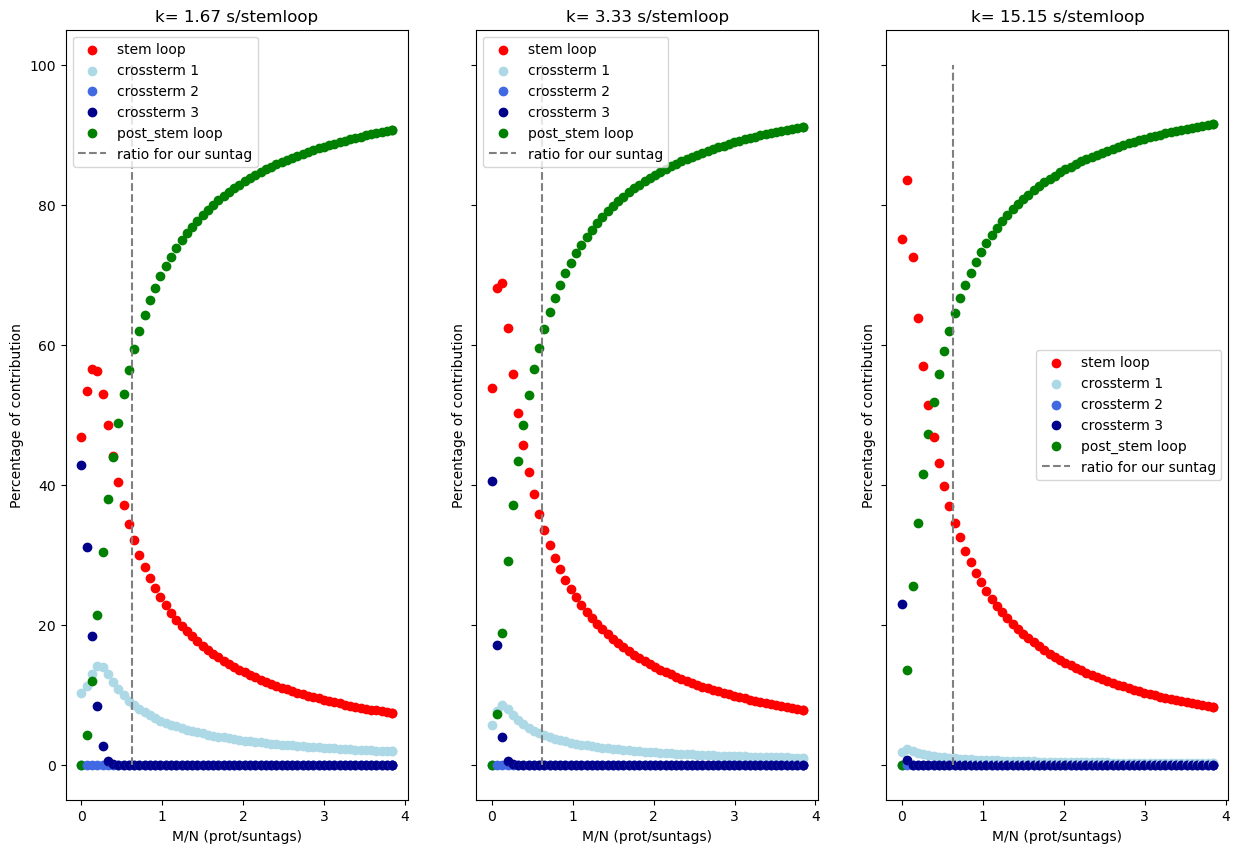

In [169]:
# estimation de la contribution de la part 1 and 5 for different ratio de prot/stemloop

tau = np.arange(0, np.int64(1200))

fig, axes = plt.subplots(ncols=3, sharey = True)

#number of stem loop
N = 32
#stem loop size
s = 24
k = 0.6
c = 0.015

i=0
for k in [0.6, 0.3, 0.066]:
    p1 = []
    p2 = []
    p3 = []
    p4 = []
    p5 = []
    
    for L in np.arange(0,3000,50):
    
        M = L/s
        
        denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
        
        k = np.float128(k)
        c = np.float128(c)
        
        part1 = c/k*np.exp(-k*tau) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*tau)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
        
        part2 = c/k*np.exp(-k*tau) * N * sum(n * ((2*N-n+1)/2) * ((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
        part3 = c/k*np.exp(-k*tau) * (N**2) * ((N+1)/2) * sum(((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (N, int(M))) /denominator
        part4 = c/k*np.exp(-k*tau) * N * sum(n *( (1+n)/2) * (((k*tau)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
        
        part5 = c/k*np.exp(-k*tau) * (N**2) * sum((M-n)*(((k*tau)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator
    
        axes[i].scatter(M/N, (part1*100/(part1+part2+part3+part4+part5))[:10].mean(), color="red")
        axes[i].scatter(M/N, (part2*100/(part1+part2+part3+part4+part5))[:10].mean(), color="lightblue")
        axes[i].scatter(M/N, (part3*100/(part1+part2+part3+part4+part5))[:10].mean(), color="royalblue")
        axes[i].scatter(M/N, (part4*100/(part1+part2+part3+part4+part5))[:10].mean(), color="darkblue")
        axes[i].scatter(M/N, (part5*100/(part1+part2+part3+part4+part5))[:10].mean(), color="green")

    # for the legend
    axes[i].scatter(M/N, (part1*100/(part1+part2+part3+part4+part5))[:10].mean(), color="red", label = "stem loop")
    axes[i].scatter(M/N, (part2*100/(part1+part2+part3+part4+part5))[:10].mean(), color="lightblue",label="crossterm 1")
    axes[i].scatter(M/N, (part3*100/(part1+part2+part3+part4+part5))[:10].mean(), color="royalblue",label="crossterm 2")
    axes[i].scatter(M/N, (part4*100/(part1+part2+part3+part4+part5))[:10].mean(), color="darkblue",label="crossterm 3")
    axes[i].scatter(M/N, (part5*100/(part1+part2+part3+part4+part5))[:10].mean(), color="green", label = "post_stem loop")
    
    # show position of suntag for us
    M = 480/s
    axes[i].vlines(M/N, 0, 100, linestyles='dashed', color='grey', label="ratio for our suntag")


    axes[i].set_xlabel("M/N (prot/suntags)")
    axes[i].set_ylabel("Percentage of contribution")
    axes[i].legend()
    axes[i].set_title("k= " + str(np.round(1/k,2))+ " s/stemloop")
    i+=1


fig.set_size_inches(15,10)

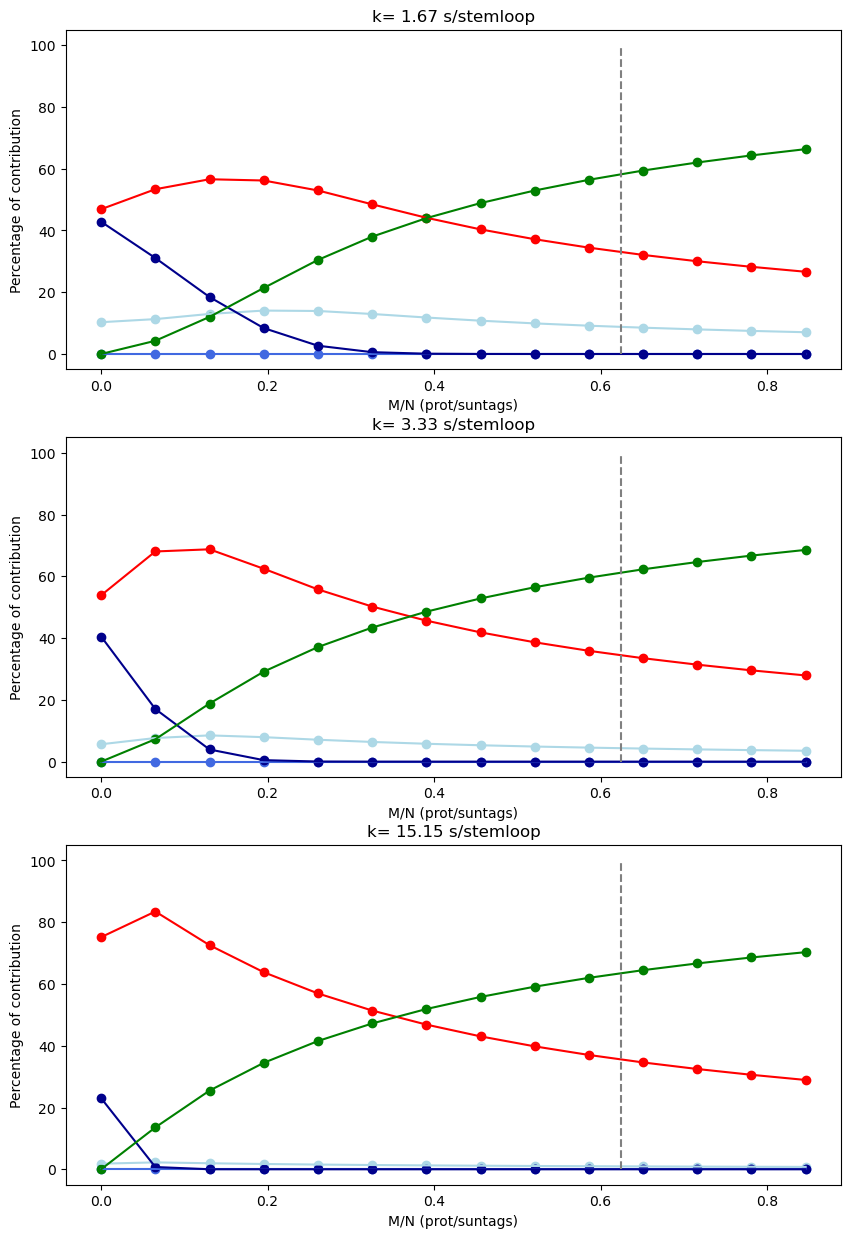

In [179]:
# estimation de la contribution de la part 1 and 5 for different ratio de prot/stemloop

tau = np.arange(0, np.int64(1200))

fig, axes = plt.subplots(nrows=3, sharey = True)

#number of stem loop
N = 32
#stem loop size
s = 24
k = 0.6
c = 0.015

i=0
for k in [0.6, 0.3, 0.066]:
    p1 = []
    p2 = []
    p3 = []
    p4 = []
    p5 = []
    MN = []
    
    # for L in np.arange(0,3000,50):
    for L in np.arange(0,700,50):
    
        M = L/s
        
        denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
        
        k = np.float128(k)
        c = np.float128(c)
        
        part1 = c/k*np.exp(-k*tau) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*tau)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
        
        part2 = c/k*np.exp(-k*tau) * N * sum(n * ((2*N-n+1)/2) * ((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
        part3 = c/k*np.exp(-k*tau) * (N**2) * ((N+1)/2) * sum(((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (N, int(M))) /denominator
        part4 = c/k*np.exp(-k*tau) * N * sum(n *( (1+n)/2) * (((k*tau)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
        
        part5 = c/k*np.exp(-k*tau) * (N**2) * sum((M-n)*(((k*tau)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator
    
        axes[i].scatter(M/N, (part1*100/(part1+part2+part3+part4+part5))[:10].mean(), color="red")
        axes[i].scatter(M/N, (part2*100/(part1+part2+part3+part4+part5))[:10].mean(), color="lightblue")
        axes[i].scatter(M/N, (part3*100/(part1+part2+part3+part4+part5))[:10].mean(), color="royalblue")
        axes[i].scatter(M/N, (part4*100/(part1+part2+part3+part4+part5))[:10].mean(), color="darkblue")
        axes[i].scatter(M/N, (part5*100/(part1+part2+part3+part4+part5))[:10].mean(), color="green")

        p1.append((part1*100/(part1+part2+part3+part4+part5))[:10].mean())
        p2.append((part2*100/(part1+part2+part3+part4+part5))[:10].mean())
        p3.append((part3*100/(part1+part2+part3+part4+part5))[:10].mean())
        p4.append((part4*100/(part1+part2+part3+part4+part5))[:10].mean())
        p5.append((part5*100/(part1+part2+part3+part4+part5))[:10].mean())
        MN.append(M/N)

    # for the legend
    axes[i].plot(MN, p1, color="red", label = "stem loop")
    axes[i].plot(MN, p2, color="lightblue",label="crossterm 1")
    axes[i].plot(MN, p3, color="royalblue",label="crossterm 2")
    axes[i].plot(MN, p4, color="darkblue",label="crossterm 3")
    axes[i].plot(MN, p5, color="green", label = "post_stem loop")
    
    # show position of suntag for us
    M = 480/s
    axes[i].vlines(M/N, 0, 100, linestyles='dashed', color='grey', label="ratio for our suntag")


    axes[i].set_xlabel("M/N (prot/suntags)")
    axes[i].set_ylabel("Percentage of contribution")
    # axes[i].legend()
    axes[i].set_title("k= " + str(np.round(1/k,2))+ " s/stemloop")
    i+=1


fig.set_size_inches(10,15)